# Explanatory Data Analysis

Goals:
    1. Familiarize yourself with the data
    2. Summarize features of particular importance
    3. Relationship between features
    4. Feature transform
    5. Example

## 1. Familiarize Yourself With the Data

#### Understand Features
* Units
* Missing values
* Format of features (continuous/categorical)
* Unusual feature format (Geospatial,Text...)

## 2. Summarize features of particular importance

* Summary statistics
    * Mean, Median, Mode, Minimum, Maximum
* Histogram
    * Comment on the type of distribution, skewness, tails, anything interesting

## 3. Relationship Between Features

* Relationship between the independent variables and the dependent variables

|     Type of Plot     |            Type of Features            |
|:--------------------:|:--------------------------------------:|
| Histogram/Count plot |      1 Continuous or 1 Categorical     |
|        Scatter       |              2 Continuous              |
|      Bar/Violin      |       1 Categorical, 1 Continuous       |
|   Scatter and Size   |              3 Continuous              |
|   Scatter and Color  | 2 Continuous, 1 Categorical/Continuous |

## 4. Feature Transforms

* Introducing new Features
    * From external data sources
    * From existing features
    * Important for obtaining better insights and better predictions

## 5. EDA Example

In [1]:
#Import required Libraries

#Data Wrangling
import numpy as np
import pandas as pd

#Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

blue = '#008FD5'
red = '#FF2700'
green = '#77AB43'

### Data for this recitation

* College dataset, 777 observation and 18 features

|   Feature   |                 Description                 |
|:-----------:|:-------------------------------------------:|
|   Private   |     "Yes" or "No" to indicate if Private    |
|     Apps    |       Number of applications received       |
|    Accept   |        Number of applicants accepted        |
|   Enroll    |       Number of new students enrolled       |
|  Top10perc  | Pct. new students from top 10% of H.S class |
|  Top25perc  | Pct. new students from top 25% of H.S class |
| F.Undergrad |     Number of full time undergraduates      |
| P.Undergrad |      Number of part time undergraduates     |
|   Outstate  |             Out of state tuition            |
|  Room.Board |             Room and Board Costs            |
|     PhD     |          Number of faculty with PhD         |
|   Terminal  |       Pct.Faculty with terminal degree      |
|  S.F.Ratio  |            Student Faculty Ratio            |
| perc.alumni |            Pct.Alumni that donate           |
|    Expend   |    Instructional expenditure per student    |
|  Grad.Rate  |               Graduation Rate               |
|    Books    |             Estimated book costs            |
|   Personal  |           Estimates personal costs          |

In [2]:
data = pd.read_csv('College.csv')

In [3]:
#Rename columns into standard form, the ols package understands _ not .
data = data.rename(columns = {'Grad.Rate':'Grad_Rate',
                              'S.F.Ratio': 'S_F_Ratio',
                              'perc.alumni':'perc_alumni',
                              'Room.Board':'Room_Board',
                              'F.Undergrad':'F_Undergrad',
                              'P.Undergrad':'P_Undergrad'})
data.head() #Preview head to get the first 5 rows of the data

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate,Names
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,Abilene Christian University
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,Adelphi University
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,Adrian College
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,Agnes Scott College
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,Alaska Pacific University


In [4]:
#Look at the summary output and pay paticular attention to if missing
data.describe()
#We see that the count for every feature is 777 which is the number of non
#missing entries, hence this is a cleaned dataset

#An interesting find is that there are schools with graduation rates >100%
#Is this a mistake? Should we ignore these schools?

,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [5]:
# List variable names to quickly check counts, data types, and if there are any null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F_Undergrad  777 non-null    int64  
 7   P_Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room_Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S_F_Ratio    777 non-null    float64
 15  perc_alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad_Rate    777 non-null    int64  
 18  Names        777 non-null    object 
dtypes: float

In [6]:
#Where is Penn?
data[data['Names']=="University of Pennsylvania"]

#100% of students place in the top 25% of their high schools in 1995! 

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate,Names
663,Yes,12394,5232,2464,85,100,9205,531,17020,7270,500,1544,95,96,6.3,38,25765,93,University of Pennsylvania


### Data Distributions - Matplotlib

Use plt.show() at the end of the codeblock or add a semicolon at the end of lines where graphing functions are invoked to suppress unwanted text output.

Text(0.5, 0, 'Graduation Rate')

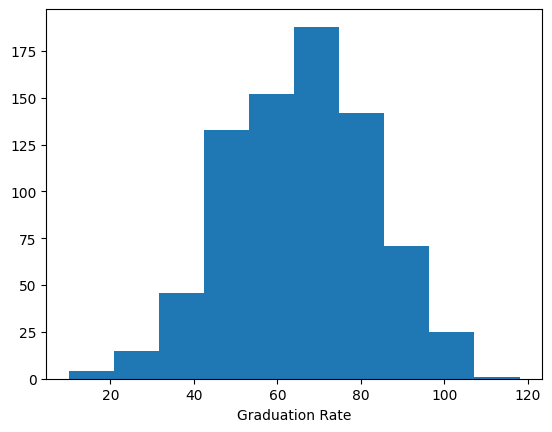

In [7]:
#Look at the Histogram of predicting variables (Graduation Rate)
plt.hist(data['Grad_Rate'],bins = 10); #Semicolon
plt.xlabel('Graduation Rate') #No semicolon

#We see in the distribution approximatly follows a normal distribution
#With a mean around 65

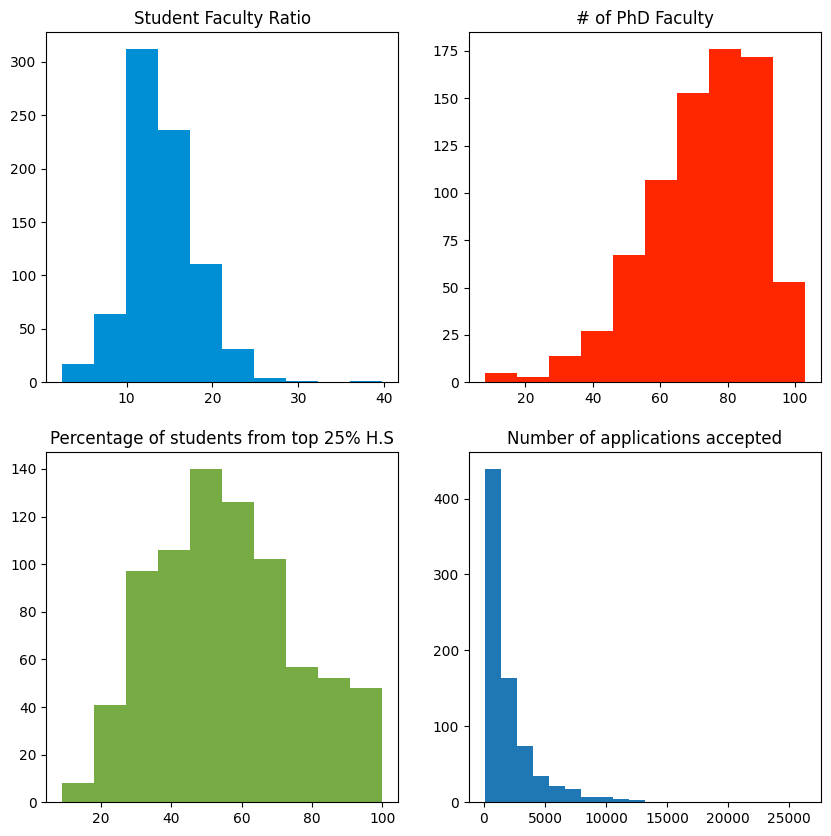

In [8]:
fig = plt.figure(figsize=(10, 10))

plt.subplot(2,2,1)
plt.hist(data['S_F_Ratio'],color = blue);
plt.title('Student Faculty Ratio');

plt.subplot(2,2,2)
plt.hist(data['PhD'],color = red);
plt.title('# of PhD Faculty');

plt.subplot(2,2,3);
plt.hist(data['Top25perc'],color = green);
plt.title('Percentage of students from top 25% H.S');

plt.subplot(2,2,4);
plt.hist(data['Accept'],bins = 20);
plt.title('Number of applications accepted');

### Feature Transform

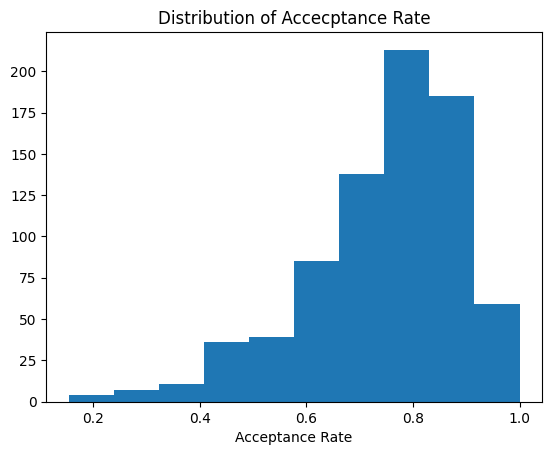

In [9]:
data2 = data.copy() #Must use copy() to assign to a new variable
data2['Accept_Rate'] = data2['Accept']/data2['Apps']
plt.hist(data2['Accept_Rate']);
plt.title('Distribution of Accecptance Rate');
plt.xlabel('Acceptance Rate');

### Seaborn - Extends the functionality of Matplotlib

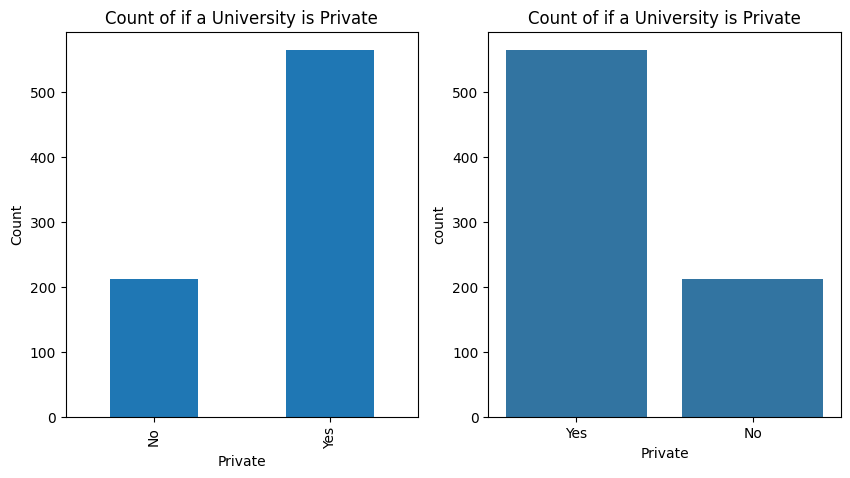

In [10]:
# Number of Private and Public Universities

fig = plt.figure(figsize=(10, 5));
counts = data2.groupby('Private').size()
plt.subplot(1,2,1);
counts.plot.bar();
plt.ylabel('Count');
plt.title('Count of if a University is Private');

plt.subplot(1,2,2);
sns.countplot(x = data['Private']);
plt.title('Count of if a University is Private');

### Exploring Relationships Between Variables

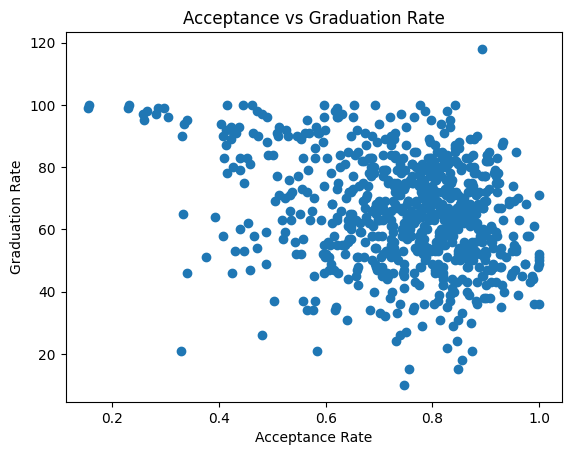

In [11]:
#Plot acceptance rate and graduation rate
plt.plot(data2['Accept_Rate'],data2['Grad_Rate'],'o');
plt.ylabel('Graduation Rate');
plt.xlabel('Acceptance Rate');
plt.title('Acceptance vs Graduation Rate');

#Shows no explicit relationship between how selective a school is and grad rate

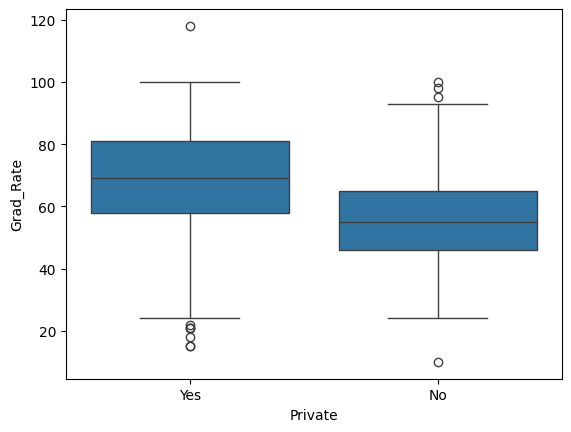

In [12]:
sns.boxplot(x = data['Private'],y = data['Grad_Rate']);

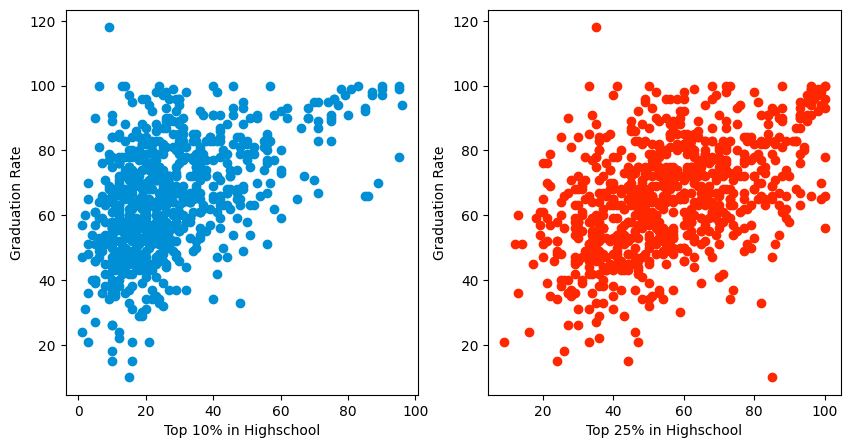

In [13]:
#Relationship between top10.perc, top25.perc and graduation rate
plt.figure(figsize=(10, 5)); #Indicate figure size

plt.subplot(1,2,1);
plt.plot(data2['Top10perc'],data2['Grad_Rate'],'o',color = blue);
plt.xlabel('Top 10% in Highschool');
plt.ylabel('Graduation Rate');


plt.subplot(1,2,2);
plt.plot(data2['Top25perc'],data2['Grad_Rate'],'o',color = red);
plt.xlabel('Top 25% in Highschool');
plt.ylabel('Graduation Rate');

#Clearly shows an increasing relationship between top students and graduation rate